# A/B testing on fully observed users

Every number here comes from `reports/metrics/test_evaluation.json` and
`reports/metrics/ab_test.json`, written by the DVC stages `final_evaluation` and `ab_test`.

**What an A/B test is.** Users are split at random into two groups. The control group (A) gets
the current system, the treatment group (B) the new one, and an outcome is compared between
the groups, here the number of videos a user likes out of the 10 a policy shows them. Because
the split is random, any difference beyond chance is caused by the policy.

**Why this simulation is unusual.** Every one of the 1,112 test users reacted to (almost)
every video, so we know what each user would have done under *both* policies. A real company
only ever sees one. Knowing both gives the **true effect**, so every statistical method below
can be checked against the right answer.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import polars as pl

from recsys.viz import style


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "dvc.yaml").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository")


ROOT = find_repo_root(Path.cwd())
METRICS, FIGURES = ROOT / "reports/metrics", ROOT / "reports/figures"
test_report = json.loads((METRICS / "test_evaluation.json").read_text(encoding="utf-8"))
ab = json.loads((METRICS / "ab_test.json").read_text(encoding="utf-8"))
METRIC = test_report["paired"]["two_tower"]["metric"]
style.apply_style()


def save(fig: plt.Figure, name: str) -> None:
    fig.savefig(FIGURES / f"{name}.png")
    plt.show()
    plt.close(fig)


def dot_whisker(ax, rows, colors, value="mean", low="ci_low", high="ci_high") -> None:
    for position, (row, color) in enumerate(zip(rows, colors, strict=True)):
        ax.plot([row[low], row[high]], [position, position], color=color, linewidth=2)
        ax.scatter(
            [row[value]], [position], s=55, color=color, edgecolors=style.SURFACE, linewidths=2
        )

## 1. The final offline evaluation (untouched test users)

The test users were never used until now. Every model is frozen: trained on the logged feed,
with settings chosen on the tune users (the re-ranker: on held-out validation users).

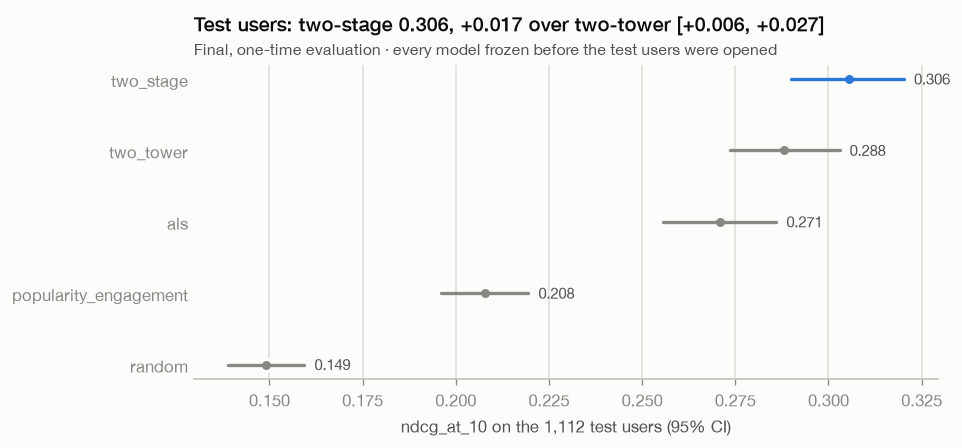

In [2]:
models = pl.DataFrame(
    [
        {
            "model": name,
            METRIC: m[METRIC],
            "ci_low": m[f"{METRIC}_ci_low"],
            "ci_high": m[f"{METRIC}_ci_high"],
            "recall_at_50": m["recall_at_50"],
            "popularity_pct_at_10": m["popularity_pct_at_10"],
        }
        for name, m in test_report["models"].items()
    ]
).sort(METRIC)
fig, ax = plt.subplots(figsize=(8, 3.4))
rows = models.to_dicts()
dot_whisker(
    ax,
    rows,
    [style.PRIMARY if r["model"] == "two_stage" else style.INK_MUTED for r in rows],
    value=METRIC,
)
for position, row in enumerate(rows):
    ax.annotate(
        f"{row[METRIC]:.3f}",
        (row["ci_high"], position),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        color=style.INK_SECONDARY,
        fontsize=9,
    )
ax.set_yticks(range(len(rows)), [r["model"] for r in rows])
ax.tick_params(axis="y", length=0)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_xlabel(f"{METRIC} on the {test_report['users']:,} test users (95% CI)")
paired = test_report["paired"]["two_tower"]["differences"]["two_stage"]
style.add_title(
    ax,
    f"Test users: two-stage {test_report['models']['two_stage'][METRIC]:.3f}, "
    f"{paired['mean']:+.3f} over two-tower [{paired['ci_low']:+.3f}, {paired['ci_high']:+.3f}]",
    "Final, one-time evaluation · every model frozen before the test users were opened",
)
save(fig, "19_test_leaderboard")

## 2. Planning the experiment: power

Before running a test you ask: *how small an effect could it reliably detect?* That is the
**minimum detectable effect** (MDE): at the planned power and false-alarm rate (conventionally
80% and 5%), it depends on how noisy the metric is and how many users each arm gets. **CUPED**
lowers it by removing the part of each user's outcome their pre-experiment behaviour already
predicts.

Turned around, an effect tells you how many users it needs. But the effect is never known in
advance: even the effect measured on these users is only an estimate of what *new* users would
show, so the table also gives the users needed across its 95% interval.

In [3]:
power, design = ab["power"], ab["design"]
print(
    f"Primary metric: {power['metric']} per session of {ab['session_length']} videos\n"
    f"Control ({power['control_policy']}) mean {power['control_mean']:.2f}, sd {power['sd']:.2f}\n"
    f"Users: {power['users_control']} control, {power['users_treatment']} treatment\n"
    f"MDE at {design['power']:.0%} power and alpha {design['alpha']:g}: {power['mde']:.3f} "
    f"({power['relative_mde']:.0%} of the mean); with CUPED {power['mde_cuped']:.3f} "
    f"(covariate correlation {power['covariate_correlation']:.2f})"
)


def users_range(needed: dict) -> str:
    fewest, most = needed["range"]
    return f"{fewest:,} to {most:,}" if most else f"{fewest:,} to unbounded"


pl.DataFrame(
    [
        {
            "experiment": name,
            "true effect": e["readout"]["true_effect"],
            "users needed (both arms)": e["users_needed"]["at_true_effect"],
            "effect for new users (95% CI)": "[{:+.2f}, {:+.2f}]".format(
                *e["users_needed"]["effect_interval"]
            ),
            "users needed across that interval": users_range(e["users_needed"]),
        }
        for name, e in ab["experiments"].items()
    ]
)

Primary metric: liked per session of 10 videos
Control (als) mean 2.65, sd 2.37
Users: 534 control, 578 treatment
MDE at 80% power and alpha 0.05: 0.398 (15% of the mean); with CUPED 0.312 (covariate correlation 0.62)


experiment,true effect,users needed (both arms),effect for new users (95% CI),users needed across that interval
str,f64,i64,str,str
"""als_vs_popularity""",0.578237,427,"""[+0.46, +0.70]""","""295 to 675"""
"""two_tower_vs_als""",0.205935,4216,"""[+0.09, +0.32]""","""1,778 to 19,906"""
"""two_stage_vs_two_tower""",0.142086,9253,"""[+0.04, +0.24]""","""3,248 to 94,975"""


## 3. The experiments, and the right answers

Each experiment splits the users once (a stable hash) and reports the difference in videos
liked, with and without CUPED. The black tick is the **true effect**, known only because the
matrix is fully observed.

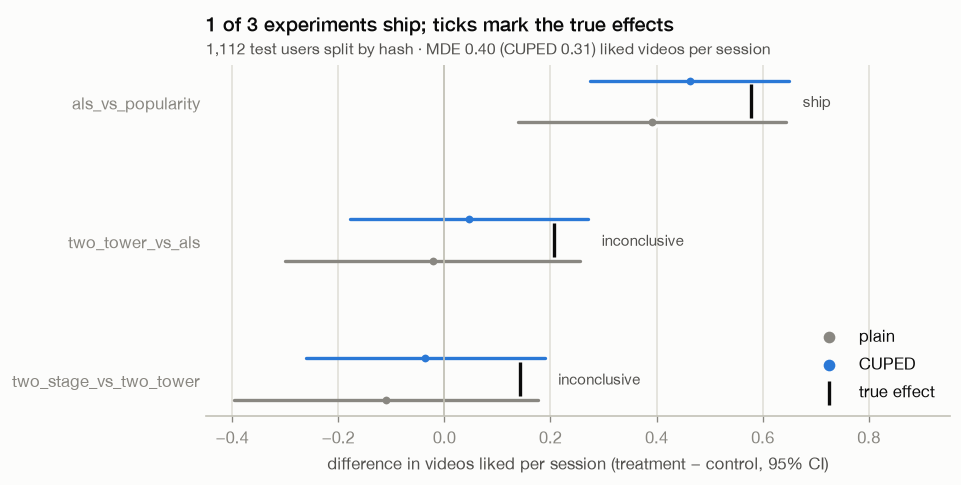

In [4]:
experiments = ab["experiments"]
names = list(experiments)[::-1]
fig, ax = plt.subplots(figsize=(8, 3.8))
for position, name in enumerate(names):
    readout = experiments[name]["readout"]
    for offset, (analysis, color) in enumerate(
        (("estimate", style.INK_MUTED), ("cuped", style.PRIMARY))
    ):
        y = position + (0.15 if offset else -0.15)
        result = readout[analysis]
        ax.plot([result["ci_low"], result["ci_high"]], [y, y], color=color, linewidth=2)
        ax.scatter(
            [result["difference"]], [y], s=45, color=color, edgecolors=style.SURFACE, linewidths=2
        )
    ax.scatter(
        [readout["true_effect"]], [position], marker="|", s=400, color=style.INK, linewidths=2
    )
    ax.annotate(
        readout["decision"],
        (max(readout["estimate"]["ci_high"], readout["cuped"]["ci_high"]), position),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        color=style.INK_SECONDARY,
        fontsize=9,
    )
ax.axvline(0, color=style.BASELINE, linewidth=1)
ax.set_yticks(range(len(names)), names)
ax.tick_params(axis="y", length=0)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_xlim(right=ax.get_xlim()[1] + 0.25)
ax.set_xlabel("difference in videos liked per session (treatment − control, 95% CI)")
ax.scatter([], [], color=style.INK_MUTED, label="plain")
ax.scatter([], [], color=style.PRIMARY, label="CUPED")
ax.scatter([], [], marker="|", s=200, color=style.INK, label="true effect")
ax.legend(loc="lower right", frameon=False)
shipped = [name for name, e in experiments.items() if e["readout"]["decision"] == "ship"]
style.add_title(
    ax,
    f"{len(shipped)} of {len(experiments)} experiments ship; ticks mark the true effects",
    f"{ab['users']:,} test users split by hash · MDE {power['mde']:.2f} "
    f"(CUPED {power['mde_cuped']:.2f}) liked videos per session",
)
save(fig, "20_ab_readouts")

## 4. Checking the statistics against the truth

Re-running each experiment with thousands of random splits shows how the method behaves:
**power** (how often it detects the true effect), **bias** (whether the estimate is right on
average) and **coverage** (whether the 95% interval contains the true effect 95% of the
time). With the same policy in both arms (an **A/A test**) every "significant" result is a
false alarm: there should be about alpha of them (5%), and p-values should spread evenly.

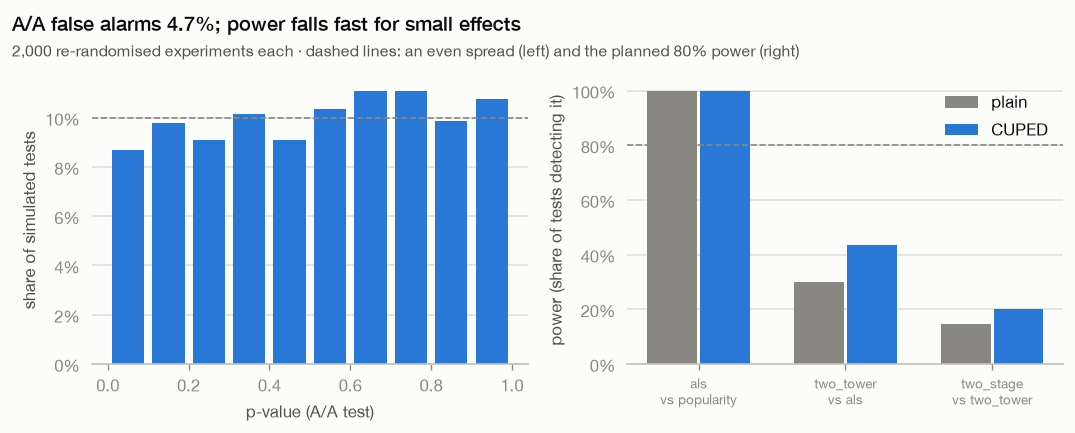

In [5]:
aa = ab["aa_test"]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
counts = np.array(aa["p_value_histogram"])
axes[0].bar(np.arange(0.05, 1, 0.1), counts / counts.sum(), width=0.08, color=style.PRIMARY)
axes[0].axhline(0.1, color=style.INK_MUTED, linewidth=1, linestyle="--")
axes[0].set_xlabel("p-value (A/A test)")
axes[0].set_ylabel("share of simulated tests")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
labels, plain, cuped = [], [], []
for name, e in experiments.items():
    labels.append(name.replace("_vs_", "\nvs "))
    plain.append(e["operating_characteristics"]["rejection_rate"])
    cuped.append(e["operating_characteristics"]["rejection_rate_cuped"])
x = np.arange(len(labels))
axes[1].bar(x - 0.18, plain, width=0.34, color=style.INK_MUTED, label="plain")
axes[1].bar(x + 0.18, cuped, width=0.34, color=style.PRIMARY, label="CUPED")
axes[1].axhline(design["power"], color=style.INK_MUTED, linewidth=1, linestyle="--")
axes[1].set_xticks(x, labels, fontsize=8)
axes[1].set_ylabel("power (share of tests detecting it)")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
axes[1].legend(loc="upper right", frameon=False)
style.add_figure_title(
    fig,
    f"A/A false alarms {aa['rejection_rate']:.1%}; power falls fast for small effects",
    f"{aa['simulations']:,} re-randomised experiments each · dashed lines: an even spread "
    f"(left) and the planned {design['power']:.0%} power (right)",
)
fig.tight_layout(rect=(0, 0, 1, style.FIGURE_TITLE_TOP))
save(fig, "21_aa_and_power")

In [6]:
pl.DataFrame(
    [
        {
            "experiment": name,
            "true effect": oc["true_effect"],
            "bias": oc["bias"],
            "coverage": oc["ci_coverage"],
            "coverage (CUPED)": oc["ci_coverage_cuped"],
            "mean CI width": oc["mean_ci_width"],
            "mean CI width (CUPED)": oc["mean_ci_width_cuped"],
        }
        for name, e in experiments.items()
        for oc in [e["operating_characteristics"]]
    ]
)

experiment,true effect,bias,coverage,coverage (CUPED),mean CI width,mean CI width (CUPED)
str,f64,f64,f64,f64,f64,f64
"""als_vs_popularity""",0.578237,0.000684,0.972,0.988,0.50215,0.38196
"""two_tower_vs_als""",0.205935,0.003524,0.974,0.983,0.56183,0.448216
"""two_stage_vs_two_tower""",0.142086,0.001231,0.961,0.968,0.574263,0.457727


**Is the hash itself fair?** The simulations above flip a coin for every user; the real
experiment splits users with a hash. Splitting the A/A comparison with many other salts checks
the hash the same way: false alarms, pre-experiment imbalance in the covariate and sample-ratio
alarms should each happen about alpha of the time.

In [7]:
assignment = ab["assignment"]
other = assignment["other_salts"]
print(
    f"Salt {assignment['salt']!r}: {assignment['users_control']} control, "
    f"{assignment['users_treatment']} treatment (SRM p = {assignment['srm_p_value']:.2f}), "
    f"covariate balance p = {assignment['covariate_balance_p_value']:.2f}\n"
    f"Over {other['assignments']:,} other salts: A/A false alarms {other['aa_rejection_rate']:.1%}, "
    f"covariate imbalance {other['covariate_imbalance_rate']:.1%}, "
    f"SRM alarms {other['srm_rejection_rate']:.1%} (alpha {design['alpha']:.0%})"
)

Salt 'kuairec-ab-v1': 534 control, 578 treatment (SRM p = 0.19), covariate balance p = 0.41
Over 2,000 other salts: A/A false alarms 5.3%, covariate imbalance 4.2%, SRM alarms 5.3% (alpha 5%)


## 5. Peeking

Checking an ordinary p-value every day and stopping at the first "significant" one feels
harmless, but every look is another chance for noise to cross the line. **Always-valid
p-values** (mSPRT) are built to be checked after every user. The price is power: mSPRT is tuned
to effects around a chosen scale (here the MDE), and detects smaller ones less often.

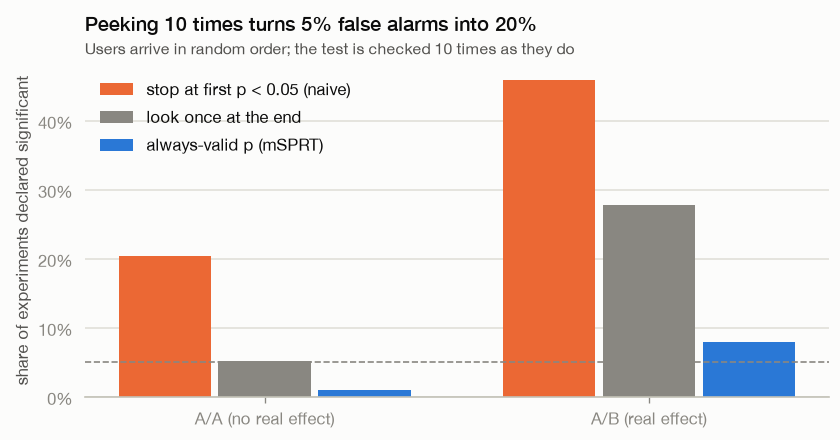

In [8]:
peek = ab["peeking"]
groups = {"A/A (no real effect)": peek["aa"], "A/B (real effect)": peek["ab"]}
rules = {
    f"stop at first p < {design['alpha']:g} (naive)": "naive_rejection_rate",
    "look once at the end": "fixed_horizon_rejection_rate",
    "always-valid p (mSPRT)": "msprt_rejection_rate",
}
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(groups))
for offset, (label, key) in enumerate(rules.items()):
    values = [group[key] for group in groups.values()]
    color = (style.SECONDARY, style.INK_MUTED, style.PRIMARY)[offset]
    ax.bar(x + (offset - 1) * 0.26, values, width=0.24, color=color, label=label)
ax.axhline(design["alpha"], color=style.INK_MUTED, linewidth=1, linestyle="--")
ax.set_xticks(x, list(groups))
ax.set_ylabel("share of experiments declared significant")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.legend(loc="upper left", frameon=False)
style.add_title(
    ax,
    f"Peeking {peek['aa']['looks']} times turns {design['alpha']:.0%} false alarms into "
    f"{peek['aa']['naive_rejection_rate']:.0%}",
    f"Users arrive in random order; the test is checked {peek['aa']['looks']} times as they do",
)
save(fig, "22_peeking")

## 6. A logging bug: sample ratio mismatch

Suppose the new version only logs a session once the user likes something, so the treatment
users who liked the least vanish from the data. Here both arms run the same policy (an A/A
comparison): the true effect is zero, and any lift is fake. Each loss is analysed exactly like
a real experiment: CUPED, then the **sample ratio mismatch** (SRM) check, which compares the
arm sizes with the intended split and declares the result invalid when the gap is too
unlikely (p < 0.001). CUPED cannot undo this bias: users were lost for how they reacted
*during* the experiment.

In [9]:
srm = ab["srm_demo"]
rows = [srm["without_bug"], *srm["drops"]]
pl.DataFrame(
    [
        {
            "users lost": f"{row['users_dropped']} ({row['drop_share']:.0%})",
            "estimate (CUPED)": row["estimate"]["difference"],
            "p-value": row["estimate"]["p_value"],
            "SRM p-value": row["srm_p_value"],
            "decision": row["decision"],
        }
        for row in rows
    ]
)

users lost,estimate (CUPED),p-value,SRM p-value,decision
str,f64,f64,f64,str
"""0 (0%)""",-0.160421,0.171545,0.187011,"""inconclusive"""
"""29 (5%)""",-0.078197,0.511536,0.648532,"""inconclusive"""
"""58 (10%)""",0.015562,0.897691,0.666302,"""inconclusive"""
"""116 (20%)""",0.239983,0.054761,0.022524,"""inconclusive"""
"""173 (30%)""",0.472265,0.000282,0.000026,"""invalid: sample ratio mismatch"""


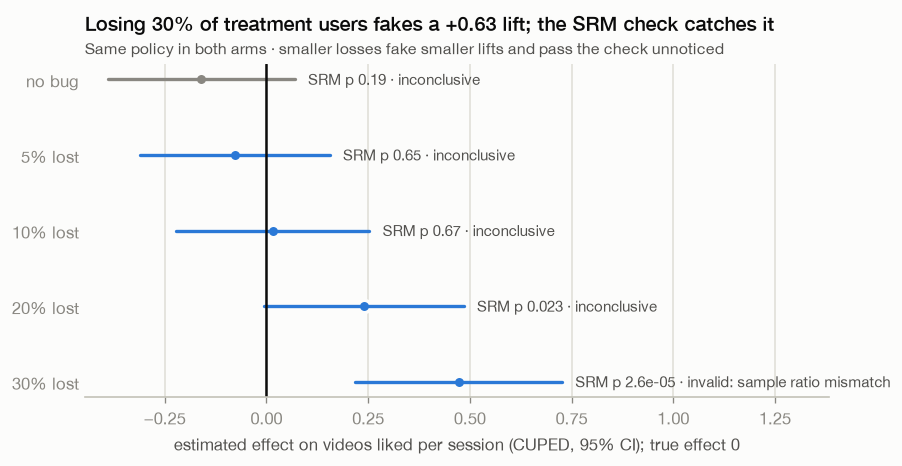

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.6))
labels = ["no bug" if not row["users_dropped"] else f"{row['drop_share']:.0%} lost" for row in rows]
estimates = [row["estimate"] for row in rows]
dot_whisker(
    ax,
    estimates,
    [style.INK_MUTED, *[style.PRIMARY] * len(srm["drops"])],
    value="difference",
)
for position, row in enumerate(rows):
    ax.annotate(
        f"SRM p {row['srm_p_value']:.2g} · {row['decision']}",
        (row["estimate"]["ci_high"], position),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        color=style.INK_SECONDARY,
        fontsize=9,
    )
ax.axvline(srm["true_effect"], color=style.INK, linewidth=1.5)
ax.set_yticks(range(len(rows)), labels)
ax.invert_yaxis()
ax.tick_params(axis="y", length=0)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_xlim(right=ax.get_xlim()[1] + 0.6)
ax.set_xlabel("estimated effect on videos liked per session (CUPED, 95% CI); true effect 0")
caught = [row for row in srm["drops"] if row["decision"].startswith("invalid")]
shift = (
    caught[0]["estimate"]["difference"] - srm["without_bug"]["estimate"]["difference"]
    if caught
    else None
)
style.add_title(
    ax,
    f"Losing {caught[0]['drop_share']:.0%} of treatment users fakes a {shift:+.2f} lift; "
    "the SRM check catches it"
    if caught
    else "No simulated loss trips the SRM check",
    "Same policy in both arms · smaller losses fake smaller lifts and pass the check unnoticed",
)
save(fig, "23_srm_demo")